In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
df = pd.read_csv('clean_comments.csv').dropna(subset=['clean_comment'])
df.shape

(54153, 3)

In [ ]:
def run_experiment(vectorizer_type, ngram_range=None, vectorizer_max_features=None):
  X_train, X_test, y_train, y_test = train_test_split(df['clean_comment'], df['category'], test_size=0.2, random_state=42, stratify=df['category'])
  if vectorizer_type == "BoW":
        vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=vectorizer_max_features)
        X_train = vectorizer.fit_transform(X_train)
        X_test = vectorizer.transform(X_test)
  elif vectorizer_type == "TF-IDF":
        vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=vectorizer_max_features)
        X_train = vectorizer.fit_transform(X_train,)
        X_test = vectorizer.transform(X_test)
  else:
        vectorizer = SentenceTransformer('all-MiniLM-L6-v2')
        X_train = vectorizer.encode(X_train.tolist(),  batch_size=64, show_progress_bar=True)
        X_test = vectorizer.encode(X_test.tolist(), batch_size=64, show_progress_bar=True)

  n_estimators = 200
  max_depth = 15

  model = RandomForestClassifier(n_estimators = n_estimators, max_depth = max_depth, random_state = 42)
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)

  print(f"accuracy score : {accuracy_score(y_pred, y_test)}")
  classification_rep = classification_report(y_test, y_pred)
  print(classification_rep)

  conf_matrix = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title(f"Confusion Matrix: {vectorizer_type}, {ngram_range}")
  plt.show()


accuracy score : 0.6361370141261194
{'0': {'precision': 0.9420289855072463, 'recall': 0.030820293978188716, 'f1-score': 0.05968778696051423, 'support': 2109.0}, '1': {'precision': 0.6598285364360074, 'recall': 0.6377626516720923, 'f1-score': 0.6486079759217457, 'support': 3379.0}, '2': {'precision': 0.6229989327641409, 'recall': 0.8740408010481003, 'f1-score': 0.7274709868369811, 'support': 5343.0}, 'accuracy': 0.6361370141261194, 'macro avg': {'precision': 0.7416188182357982, 'recall': 0.5142079155661271, 'f1-score': 0.47858891657308034, 'support': 10831.0}, 'weighted avg': {'precision': 0.6966100131853805, 'recall': 0.6361370141261194, 'f1-score': 0.5728377228334681, 'support': 10831.0}}


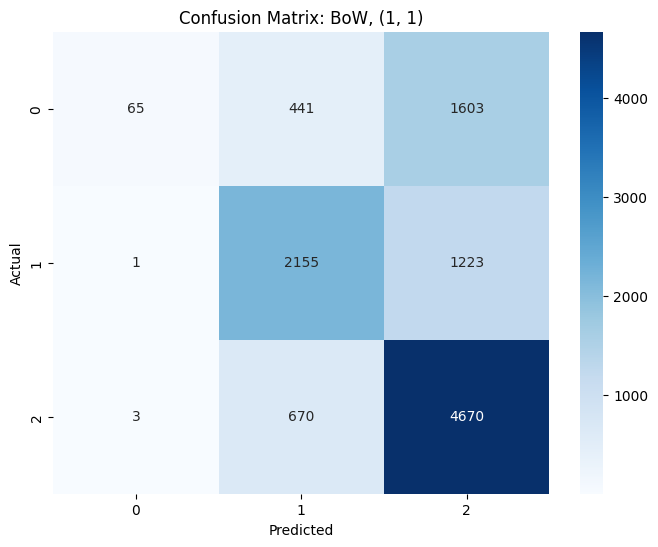

accuracy score : 0.6401994275690148
{'0': {'precision': 0.9529411764705882, 'recall': 0.03840682788051209, 'f1-score': 0.07383773928896992, 'support': 2109.0}, '1': {'precision': 0.6597721822541966, 'recall': 0.6513761467889908, 'f1-score': 0.6555472822040208, 'support': 3379.0}, '2': {'precision': 0.6278002699055331, 'recall': 0.8706719071682575, 'f1-score': 0.7295538304712617, 'support': 5343.0}, 'accuracy': 0.6401994275690148, 'macro avg': {'precision': 0.746837876210106, 'recall': 0.5201516272792535, 'f1-score': 0.4863129506547508, 'support': 10831.0}, 'weighted avg': {'precision': 0.7010857711308894, 'recall': 0.6401994275690148, 'f1-score': 0.5787853545319708, 'support': 10831.0}}


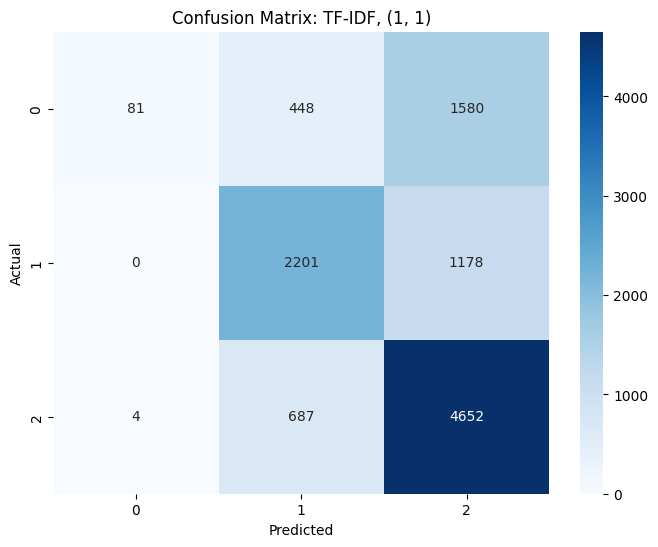

accuracy score : 0.6364139968608623
{'0': {'precision': 0.9444444444444444, 'recall': 0.03224276908487435, 'f1-score': 0.062356717102246675, 'support': 2109.0}, '1': {'precision': 0.65748031496063, 'recall': 0.6424977804084049, 'f1-score': 0.6499027091752732, 'support': 3379.0}, '2': {'precision': 0.6241115730186402, 'recall': 0.8710462287104623, 'f1-score': 0.7271875, 'support': 5343.0}, 'accuracy': 0.6364139968608623, 'macro avg': {'precision': 0.7420121108079049, 'recall': 0.5152622594012471, 'f1-score': 0.4798156420925066, 'support': 10831.0}, 'weighted avg': {'precision': 0.6968966348650998, 'recall': 0.6364139968608623, 'f1-score': 0.573621492306517, 'support': 10831.0}}


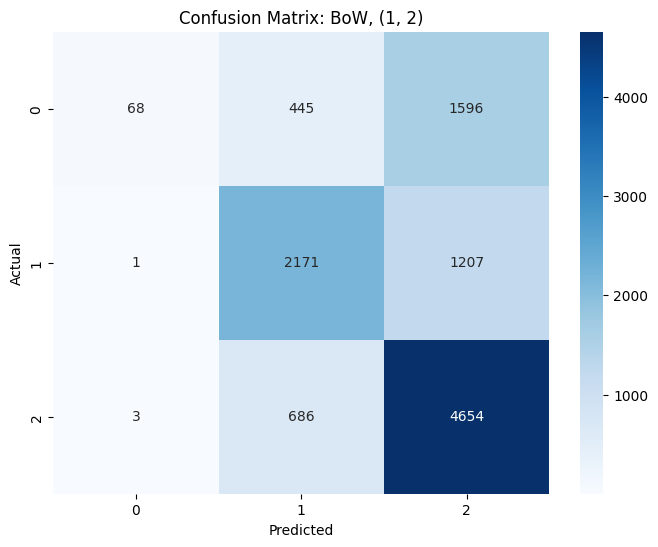

accuracy score : 0.6395531345212815
{'0': {'precision': 0.9487179487179487, 'recall': 0.03508771929824561, 'f1-score': 0.06767261088248742, 'support': 2109.0}, '1': {'precision': 0.6600361663652803, 'recall': 0.648120745782776, 'f1-score': 0.6540241899357921, 'support': 3379.0}, '2': {'precision': 0.6271687962340282, 'recall': 0.8727306756503836, 'f1-score': 0.7298481765534512, 'support': 5343.0}, 'accuracy': 0.6395531345212815, 'macro avg': {'precision': 0.7453076371057524, 'recall': 0.5186463802438017, 'f1-score': 0.48384832579057696, 'support': 10831.0}, 'weighted avg': {'precision': 0.700034275530685, 'recall': 0.6395531345212815, 'f1-score': 0.5772549239654046, 'support': 10831.0}}


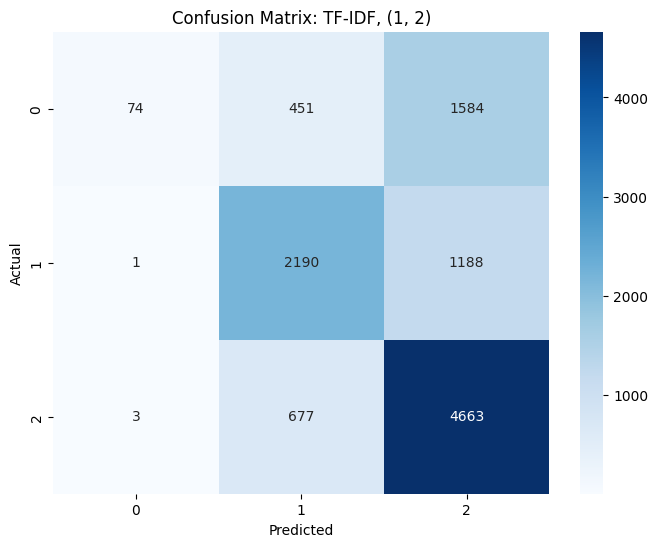

accuracy score : 0.6404764103037577
{'0': {'precision': 0.9333333333333333, 'recall': 0.03982930298719772, 'f1-score': 0.07639836289222374, 'support': 2109.0}, '1': {'precision': 0.6604455147501506, 'recall': 0.6493045279668541, 'f1-score': 0.65482763766602, 'support': 3379.0}, '2': {'precision': 0.627982207844723, 'recall': 0.8719820325659742, 'f1-score': 0.7301363422661025, 'support': 5343.0}, 'accuracy': 0.6404764103037577, 'macro avg': {'precision': 0.7405870186427356, 'recall': 0.5203719545066753, 'f1-score': 0.4871207809414488, 'support': 10831.0}, 'weighted avg': {'precision': 0.6975675681705396, 'recall': 0.6404764103037577, 'f1-score': 0.5793468019334287, 'support': 10831.0}}


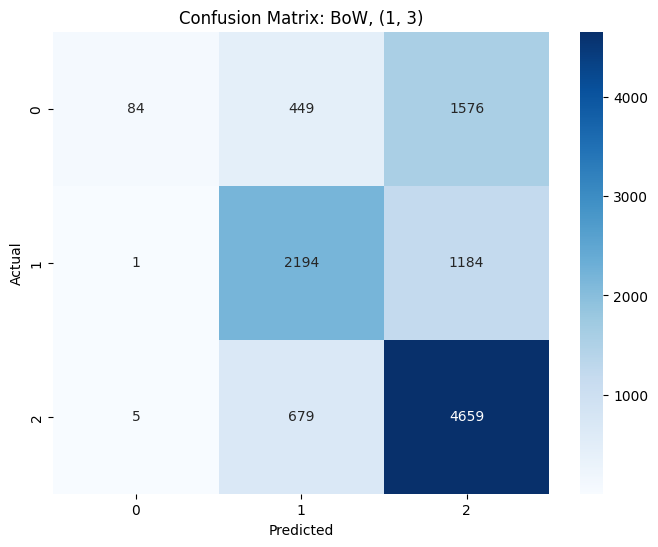

accuracy score : 0.6400147724125196
{'0': {'precision': 0.9468085106382979, 'recall': 0.04220009483167378, 'f1-score': 0.08079891057648661, 'support': 2109.0}, '1': {'precision': 0.6549881235154394, 'recall': 0.6528558745190884, 'f1-score': 0.6539202608566771, 'support': 3379.0}, '2': {'precision': 0.6292577011806215, 'recall': 0.8678644956017219, 'f1-score': 0.7295468848332285, 'support': 5343.0}, 'accuracy': 0.6400147724125196, 'macro avg': {'precision': 0.7436847784447863, 'recall': 0.5209734883174947, 'f1-score': 0.48808868542213074, 'support': 10831.0}, 'weighted avg': {'precision': 0.6991180791896316, 'recall': 0.6400147724125196, 'f1-score': 0.579629809759437, 'support': 10831.0}}


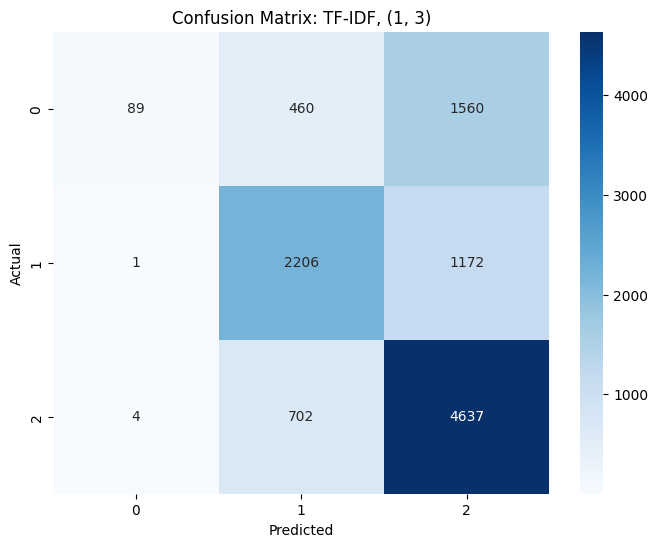

In [22]:
ngram_ranges = [(1, 1), (1, 2), (1, 3)]
max_features = 1000

for ngram_range in ngram_ranges:
    # BoW Experiments
    run_experiment("BoW", ngram_range, max_features)

    # TF-IDF Experiments
    run_experiment("TF-IDF", ngram_range, max_features)

Sentence Transformers are taking too much time😭, give me Good GPU, amm not even trying BERT. BEST PERFORMANCE BY BoW (1, 3)